# Notebook 2 — Data Cleaning & Preprocessing
**Credit Card Fraud Detection | IS525E Data Science for Business**

Steps:
1. Scale `Time` and `Amount` features
2. Handle class imbalance (SMOTE oversampling)
3. Train/test split
4. Save processed data for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')

Shape: (284807, 31)
Missing values: 0


## 2. Scale Time and Amount

In [3]:
scaler = StandardScaler()
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Drop original unscaled columns
df = df.drop(columns=['Time', 'Amount'])
print('Scaled Time and Amount. New shape:', df.shape)

Scaled Time and Amount. New shape: (284807, 31)


## 3. Train/Test Split

In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Train fraud rate: {y_train.mean():.4%}')
print(f'Test fraud rate:  {y_test.mean():.4%}')

Train size: 227,845 | Test size: 56,962
Train fraud rate: 0.1729%
Test fraud rate:  0.1720%


## 4. Handle Class Imbalance with SMOTE

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64



After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


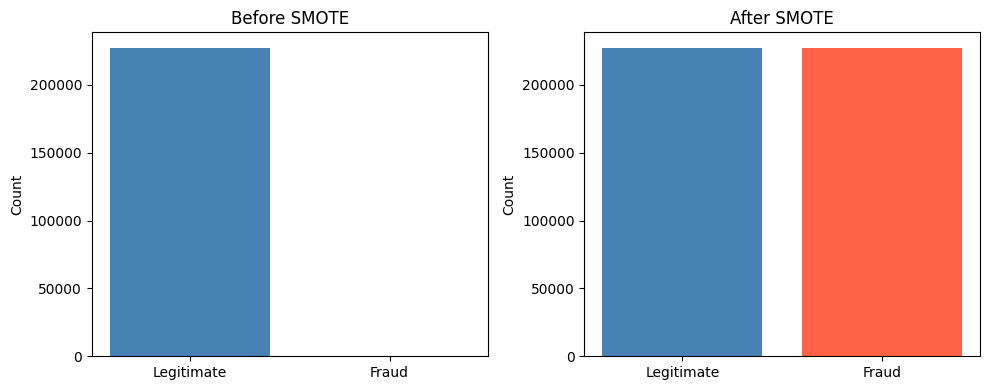

In [5]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_res).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE'),
    (pd.Series(y_train_res).value_counts(), 'After SMOTE')
]):
    ax.bar(['Legitimate', 'Fraud'], counts, color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/smote_comparison.png', dpi=150)
plt.show()

## 5. Save Processed Splits

In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)
X_train_res_df['Class'] = y_train_res
X_train_res_df.to_csv('../data/processed/train_resampled.csv', index=False)

X_test_df = X_test.copy()
X_test_df['Class'] = y_test.values
X_test_df.to_csv('../data/processed/test.csv', index=False)

print('Saved: data/processed/train_resampled.csv')
print('Saved: data/processed/test.csv')

Saved: data/processed/train_resampled.csv
Saved: data/processed/test.csv


## Summary

- `Time` and `Amount` scaled using `StandardScaler`
- Stratified 80/20 train/test split preserves original fraud ratio
- SMOTE applied to training set only (never to test set — avoids data leakage)
- Processed splits saved for modeling

**Next step:** Notebook 03 — Modeling